# Análise de Experimentos FL

In [2]:
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

In [3]:
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

## 1. Exploração dos logs

In [4]:
BASE_DIR = Path("/home/joaobbb/research/experiments/fashionmnist_gpu")
BASE_DIR

PosixPath('/home/joaobbb/research/experiments/fashionmnist_gpu')

In [5]:
BASE_DIR.exists(), BASE_DIR.is_dir()

(True, True)

In [6]:
algorithms = sorted([p.name for p in BASE_DIR.iterdir() if p.is_dir()])
algorithms

['FedAvg', 'FedProx', 'SCAFFOLD']

In [7]:
def parse_join_ratio(jr_folder_name: str) -> float:
    mapping = {
        "jr01": 0.10,
        "jr025": 0.25,
        "jr05": 0.50,
        "jr075": 0.75,
        "jr10": 1.00,
    }
    if jr_folder_name not in mapping:
        raise ValueError(f"Join ratio desconhecido: {jr_folder_name}")
    return mapping[jr_folder_name]

In [8]:
rows = []

for algo_dir in BASE_DIR.iterdir():
    if not algo_dir.is_dir():
        continue
    
    algorithm = algo_dir.name
    
    for jr_dir in algo_dir.iterdir():
        if not jr_dir.is_dir():
            continue
        
        jr_name = jr_dir.name
        
        try:
            join_ratio = parse_join_ratio(jr_name)
        except ValueError:
            print(f"Ignorando pasta não reconhecida: {jr_dir}")
            continue
        
        for rep_dir in jr_dir.iterdir():
            if not rep_dir.is_dir():
                continue
            
            rep_name = rep_dir.name
            
            rows.append({
                "algorithm": algorithm,
                "jr_folder": jr_name,
                "join_ratio": join_ratio,
                "rep": rep_name,
                "rep_path": rep_dir,
                "raw_log_path": rep_dir / "raw_log.txt",
                "cpu_log_path": rep_dir / "cpu_usage.log",
                "gpu_csv_path": rep_dir / "gpu_usage.csv",
                "meta_info_path": rep_dir / "meta_info.txt",
            })

df_inventory = pd.DataFrame(rows)
df_inventory.head()

,algorithm,jr_folder,join_ratio,rep,rep_path,raw_log_path,cpu_log_path,gpu_csv_path,meta_info_path
0,FedAvg,jr075,0.75,rep1,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...
1,FedAvg,jr075,0.75,rep3,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...
2,FedAvg,jr075,0.75,rep5,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...
3,FedAvg,jr075,0.75,rep2,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...
4,FedAvg,jr075,0.75,rep4,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...,/home/joaobbb/research/experiments/fashionmnis...


In [9]:
len(df_inventory)

76

In [10]:
df_inventory.groupby(["algorithm", "jr_folder"]).size().sort_index()

algorithm  jr_folder
FedAvg     jr01         5
           jr025        5
           jr05         5
           jr075        5
           jr10         5
FedProx    jr01         5
           jr025        5
           jr05         5
           jr075        5
           jr10         5
SCAFFOLD   jr01         5
           jr025        5
           jr05         5
           jr075        6
           jr10         5
dtype: int64

In [11]:
for col in ["raw_log_path", "cpu_log_path", "gpu_csv_path"]:
    df_inventory[f"{col}_exists"] = df_inventory[col].apply(lambda p: p.exists())

df_inventory[[
    "algorithm", "jr_folder", "rep",
    "raw_log_path_exists", "cpu_log_path_exists", "gpu_csv_path_exists"
]].head(10)

,algorithm,jr_folder,rep,raw_log_path_exists,cpu_log_path_exists,gpu_csv_path_exists
0,FedAvg,jr075,rep1,True,True,True
1,FedAvg,jr075,rep3,True,True,True
2,FedAvg,jr075,rep5,True,True,True
3,FedAvg,jr075,rep2,True,True,True
4,FedAvg,jr075,rep4,True,True,True
5,FedAvg,jr05,rep1,True,True,True
6,FedAvg,jr05,rep3,True,True,True
7,FedAvg,jr05,rep5,True,True,True
8,FedAvg,jr05,rep2,True,True,True
9,FedAvg,jr05,rep4,True,True,True


In [12]:
df_inventory[[
    "raw_log_path_exists",
    "cpu_log_path_exists",
    "gpu_csv_path_exists"
]].value_counts()

raw_log_path_exists  cpu_log_path_exists  gpu_csv_path_exists
True                 True                 True                   76
Name: count, dtype: int64

### 1.1 Leitura do raw_log


In [13]:
test_row = df_inventory[
    (df_inventory["algorithm"] == "FedAvg") &
    (df_inventory["jr_folder"] == "jr01") &
    (df_inventory["rep"] == "rep1")
].iloc[0]

test_row

algorithm                                                         FedAvg
jr_folder                                                           jr01
join_ratio                                                           0.1
rep                                                                 rep1
rep_path               /home/joaobbb/research/experiments/fashionmnis...
raw_log_path           /home/joaobbb/research/experiments/fashionmnis...
cpu_log_path           /home/joaobbb/research/experiments/fashionmnis...
gpu_csv_path           /home/joaobbb/research/experiments/fashionmnis...
meta_info_path         /home/joaobbb/research/experiments/fashionmnis...
raw_log_path_exists                                                 True
cpu_log_path_exists                                                 True
gpu_csv_path_exists                                                 True
Name: 10, dtype: object

In [14]:
raw_log_path = test_row["raw_log_path"]

with open(raw_log_path, "r") as f:
    raw_text = f.read()

print(raw_text[:2000])  # só para visualizar início

goal = test
device = cuda
device_id = 0
dataset = FashionMNIST
num_classes = 10
model = CNN
batch_size = 10
local_learning_rate = 0.005
learning_rate_decay = False
learning_rate_decay_gamma = 0.99
global_rounds = 50
top_cnt = 100
local_epochs = 5
algorithm = FedAvg
join_ratio = 0.1
random_join_ratio = False
num_clients = 100
prev = 0
times = 1
eval_gap = 1
save_folder_name = FashionMNIST_FedAvg_gpu_jr01_rep1
auto_break = False
dlg_eval = False
dlg_gap = 100
batch_num_per_client = 2
num_new_clients = 0
fine_tuning_epoch_new = 0
feature_dim = 512
vocab_size = 80
max_len = 200
few_shot = 0
client_drop_rate = 0.0
train_slow_rate = 0.0
send_slow_rate = 0.0
time_select = False
time_threthold = 10000
beta = 0.0
lamda = 1.0
mu = 0.0
K = 5
p_learning_rate = 0.01
M = 5
itk = 4000
alphaK = 1.0
sigma = 1.0
alpha = 1.0
plocal_epochs = 1
tau = 1.0
fine_tuning_epochs = 10
dr_learning_rate = 0.0
L = 1.0
noise_dim = 512
generator_learning_rate = 0.005
hidden_dim = 512
server_epochs = 1000
localize_feat

In [15]:
best_acc_match = re.search(r"Best accuracy.\s*\n([0-9\.]+)", raw_text)
total_time_match = re.search(r"Average time cost:\s*([0-9\.]+)s", raw_text)

best_acc = float(best_acc_match.group(1)) if best_acc_match else None
total_time = float(total_time_match.group(1)) if total_time_match else None

best_acc, total_time

(0.6978285714285715, 1709.63)

In [16]:
round_pattern = re.compile(
    r"\[(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\]\s+[-]+Round number:\s+(\d+)[-]+.*?"
    r"Averaged Train Loss:\s+([0-9.]+).*?"
    r"Averaged Test Accuracy:\s+([0-9.]+).*?"
    r"time cost\s+[-]+\s+([0-9.]+)",
    re.DOTALL
)

rounds_data = []

for match in round_pattern.finditer(raw_text):
    timestamp_str = match.group(1)
    round_num = int(match.group(2))
    train_loss = float(match.group(3))
    test_acc = float(match.group(4))
    time_cost = float(match.group(5))

    timestamp = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S")

    rounds_data.append({
        "round": round_num,
        "timestamp": timestamp,
        "train_loss": train_loss,
        "test_acc": test_acc,
        "time_cost": time_cost
    })

df_rounds = pd.DataFrame(rounds_data)
df_rounds.head()

,round,timestamp,train_loss,test_acc,time_cost
0,0,2026-04-08 20:25:08,2.3126,0.0569,36.637629
1,1,2026-04-08 20:25:45,2.9716,0.1974,49.631271
2,2,2026-04-08 20:26:34,2.3063,0.2205,45.272339
3,3,2026-04-08 20:27:20,2.9567,0.1957,43.350915
4,4,2026-04-08 20:28:03,1.8203,0.3186,56.152009


In [17]:
len(df_rounds)

51

In [18]:
df_rounds.head()

,round,timestamp,train_loss,test_acc,time_cost
0,0,2026-04-08 20:25:08,2.3126,0.0569,36.637629
1,1,2026-04-08 20:25:45,2.9716,0.1974,49.631271
2,2,2026-04-08 20:26:34,2.3063,0.2205,45.272339
3,3,2026-04-08 20:27:20,2.9567,0.1957,43.350915
4,4,2026-04-08 20:28:03,1.8203,0.3186,56.152009


In [19]:
df_rounds.tail()

,round,timestamp,train_loss,test_acc,time_cost
46,46,2026-04-08 20:51:31,0.9256,0.6337,24.876439
47,47,2026-04-08 20:51:56,0.9959,0.6103,25.121776
48,48,2026-04-08 20:52:21,1.1866,0.6173,25.553770
49,49,2026-04-08 20:52:47,0.7965,0.6978,24.756414
50,50,2026-04-08 20:53:12,1.0089,0.6687,22.770836


### 1.2 CPU e GPU

In [20]:
cpu_log_path = test_row["cpu_log_path"]

with open(cpu_log_path, "r") as f:
    cpu_text = f.read()

print(cpu_text[:2000])

Linux 6.6.87.2-microsoft-standard-WSL2 (Notebook) 	04/08/26 	_x86_64_	(8 CPU)

# Time        UID       PID    %usr %system  %guest   %wait    %CPU   CPU  minflt/s  majflt/s     VSZ     RSS   %MEM   kB_rd/s   kB_wr/s kB_ccwr/s iodelay  Command
20:25:04     1000     11554  169.00   19.00    0.00    0.00  188.00     7  28424.00      0.00 4108308  499928   6.23      0.00      0.00      0.00       0  python

# Time        UID       PID    %usr %system  %guest   %wait    %CPU   CPU  minflt/s  majflt/s     VSZ     RSS   %MEM   kB_rd/s   kB_wr/s kB_ccwr/s iodelay  Command
20:25:05     1000     11554   67.00   24.00    0.00    0.00   91.00     6  68502.00    155.00 25869760  810884  10.11   6956.00      4.00      0.00       0  python

# Time        UID       PID    %usr %system  %guest   %wait    %CPU   CPU  minflt/s  majflt/s     VSZ     RSS   %MEM   kB_rd/s   kB_wr/s kB_ccwr/s iodelay  Command
20:25:06     1000     11554   51.00   52.00    0.00    0.00  103.00     7 137579.00      0.00 263986

In [21]:
cpu_pattern = re.compile(
    r"^(\d{2}:\d{2}:\d{2})\s+\d+\s+\d+\s+([0-9.]+)\s+([0-9.]+)\s+[0-9.]+\s+[0-9.]+\s+([0-9.]+)\s+\d+.*?\bpython\b",
    re.MULTILINE
)

cpu_rows = []

for match in cpu_pattern.finditer(cpu_text):
    time_str = match.group(1)
    usr = float(match.group(2))
    system = float(match.group(3))
    cpu_total = float(match.group(4))
    
    cpu_rows.append({
        "time_str": time_str,
        "cpu_usr": usr,
        "cpu_system": system,
        "cpu_total": cpu_total
    })

df_cpu = pd.DataFrame(cpu_rows)
df_cpu.head()

,time_str,cpu_usr,cpu_system,cpu_total
0,20:25:04,169.0,19.0,188.0
1,20:25:05,67.0,24.0,91.0
2,20:25:06,51.0,52.0,103.0
3,20:25:07,79.0,26.0,105.0
4,20:25:08,95.0,11.0,106.0


In [22]:
base_date = df_rounds["timestamp"].dt.date.iloc[0]
base_date

df_cpu["timestamp"] = pd.to_datetime(
    df_cpu["time_str"].apply(lambda x: f"{base_date} {x}")
)

df_cpu = df_cpu[["timestamp", "cpu_usr", "cpu_system", "cpu_total"]]
df_cpu.head()

,timestamp,cpu_usr,cpu_system,cpu_total
0,2026-04-08 20:25:04,169.0,19.0,188.0
1,2026-04-08 20:25:05,67.0,24.0,91.0
2,2026-04-08 20:25:06,51.0,52.0,103.0
3,2026-04-08 20:25:07,79.0,26.0,105.0
4,2026-04-08 20:25:08,95.0,11.0,106.0


In [23]:
len(df_cpu), df_cpu["timestamp"].min(), df_cpu["timestamp"].max()

df_cpu.describe()

,timestamp,cpu_usr,cpu_system,cpu_total
count,1602,1602.000000,1602.000000,1602.000000
mean,2026-04-08 20:39:21.500000,95.323221,11.625843,106.949064
min,2026-04-08 20:25:04,51.000000,0.000000,91.000000
25%,2026-04-08 20:32:13.750000,91.000000,8.000000,106.000000
50%,2026-04-08 20:39:23.500000,95.000000,12.000000,106.000000
75%,2026-04-08 20:46:28.750000,100.000000,15.000000,108.000000
max,2026-04-08 20:53:36,169.000000,52.000000,188.000000
std,NaN,6.588236,5.530944,3.438292


In [24]:
gpu_csv_path = test_row["gpu_csv_path"]

df_gpu = pd.read_csv(gpu_csv_path)
df_gpu.head()

,timestamp,gpu_name,utilization_gpu_pct,utilization_memory_pct,memory_used_mib,memory_total_mib,temperature_gpu_c,power_draw_w
0,2026/04/08 20:25:03.840,NVIDIA GeForce MX230,0,0,0,2048,57,[N/A]
1,2026/04/08 20:25:04.845,NVIDIA GeForce MX230,0,0,0,2048,58,[N/A]
2,2026/04/08 20:25:05.849,NVIDIA GeForce MX230,13,1,78,2048,60,[N/A]
3,2026/04/08 20:25:06.850,NVIDIA GeForce MX230,9,1,274,2048,61,[N/A]
4,2026/04/08 20:25:07.851,NVIDIA GeForce MX230,2,1,464,2048,62,[N/A]


In [25]:
df_gpu["timestamp"] = pd.to_datetime(df_gpu["timestamp"])
df_gpu.head()

,timestamp,gpu_name,utilization_gpu_pct,utilization_memory_pct,memory_used_mib,memory_total_mib,temperature_gpu_c,power_draw_w
0,2026-04-08 20:25:03.840,NVIDIA GeForce MX230,0,0,0,2048,57,[N/A]
1,2026-04-08 20:25:04.845,NVIDIA GeForce MX230,0,0,0,2048,58,[N/A]
2,2026-04-08 20:25:05.849,NVIDIA GeForce MX230,13,1,78,2048,60,[N/A]
3,2026-04-08 20:25:06.850,NVIDIA GeForce MX230,9,1,274,2048,61,[N/A]
4,2026-04-08 20:25:07.851,NVIDIA GeForce MX230,2,1,464,2048,62,[N/A]


In [26]:
df_gpu = df_gpu[[
    "timestamp",
    "utilization_gpu_pct",
    "memory_used_mib"
]]

df_gpu = df_gpu.rename(columns={
    "utilization_gpu_pct": "gpu_util",
    "memory_used_mib": "gpu_mem"
})

df_gpu.head()

,timestamp,gpu_util,gpu_mem
0,2026-04-08 20:25:03.840,0,0
1,2026-04-08 20:25:04.845,0,0
2,2026-04-08 20:25:05.849,13,78
3,2026-04-08 20:25:06.850,9,274
4,2026-04-08 20:25:07.851,2,464


In [27]:
len(df_gpu), df_gpu["timestamp"].min(), df_gpu["timestamp"].max()

df_gpu.describe()

,timestamp,gpu_util,gpu_mem
count,1599,1599.000000,1599.000000
mean,2026-04-08 20:39:21.211806,61.563477,1045.703565
min,2026-04-08 20:25:03.840000,0.000000,0.000000
25%,2026-04-08 20:32:12.608000,46.000000,994.000000
50%,2026-04-08 20:39:23.415000,61.000000,1084.000000
75%,2026-04-08 20:46:28.770500,76.500000,1106.000000
max,2026-04-08 20:53:35.439000,99.000000,1106.000000
std,NaN,21.312522,83.690650


In [28]:
df_rounds = df_rounds.sort_values("timestamp").reset_index(drop=True)

df_rounds["end_time"] = df_rounds["timestamp"].shift(-1)
df_rounds.loc[df_rounds.index[-1], "end_time"] = df_rounds.loc[df_rounds.index[-1], "timestamp"]

In [29]:
cpu_means = []
gpu_means = []

for _, row in df_rounds.iterrows():
    start = row["timestamp"]
    end = row["end_time"]
    
    cpu_slice = df_cpu[(df_cpu["timestamp"] >= start) & (df_cpu["timestamp"] < end)]
    gpu_slice = df_gpu[(df_gpu["timestamp"] >= start) & (df_gpu["timestamp"] < end)]
    
    cpu_mean = cpu_slice["cpu_total"].mean() if not cpu_slice.empty else np.nan
    gpu_mean = gpu_slice["gpu_util"].mean() if not gpu_slice.empty else np.nan
    
    cpu_means.append(cpu_mean)
    gpu_means.append(gpu_mean)

df_rounds["cpu_mean"] = cpu_means
df_rounds["gpu_mean"] = gpu_means

df_rounds.head()

,round,timestamp,train_loss,test_acc,time_cost,end_time,cpu_mean,gpu_mean
0,0,2026-04-08 20:25:08,2.3126,0.0569,36.637629,2026-04-08 20:25:45,106.914286,70.323529
1,1,2026-04-08 20:25:45,2.9716,0.1974,49.631271,2026-04-08 20:26:34,107.043864,75.244444
2,2,2026-04-08 20:26:34,2.3063,0.2205,45.272339,2026-04-08 20:27:20,106.954545,81.511628
3,3,2026-04-08 20:27:20,2.9567,0.1957,43.350915,2026-04-08 20:28:03,107.250000,81.853659
4,4,2026-04-08 20:28:03,1.8203,0.3186,56.152009,2026-04-08 20:28:59,106.903846,83.431373


In [30]:
df_rounds[[
    "round",
    "test_acc",
    "time_cost",
    "cpu_mean",
    "gpu_mean"
]].head(10)

,round,test_acc,time_cost,cpu_mean,gpu_mean
0,0,0.0569,36.637629,106.914286,70.323529
1,1,0.1974,49.631271,107.043864,75.244444
2,2,0.2205,45.272339,106.954545,81.511628
3,3,0.1957,43.350915,107.250000,81.853659
4,4,0.3186,56.152009,106.903846,83.431373
5,5,0.2257,77.114202,107.818889,81.833333
6,6,0.4247,70.119261,107.661538,76.907692
7,7,0.4663,90.456505,107.236786,79.289157
8,8,0.5014,89.830343,108.164706,72.494118
9,9,0.6017,31.497396,107.642857,74.827586


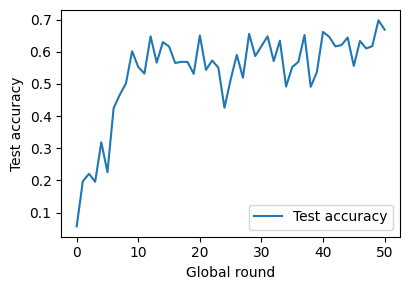

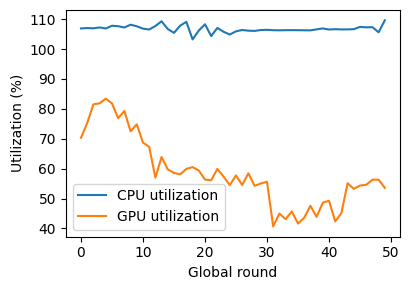

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.2, 3.0))

ax.plot(
    df_rounds["round"],
    df_rounds["test_acc"],
    label="Test accuracy"
)

ax.set_xlabel("Global round")
ax.set_ylabel("Test accuracy")
ax.legend(loc="lower right", frameon=True)

fig.tight_layout()
fig.savefig("fig_representative_test_accuracy.pdf", bbox_inches="tight")
plt.show()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.2, 3.0))

ax.plot(
    df_rounds["round"],
    df_rounds["cpu_mean"],
    label="CPU utilization"
)

ax.plot(
    df_rounds["round"],
    df_rounds["gpu_mean"],
    label="GPU utilization"
)

ax.set_xlabel("Global round")
ax.set_ylabel("Utilization (%)")
ax.legend(loc="lower left", frameon=True)

fig.tight_layout()
fig.savefig("fig_representative_resource_usage.pdf", bbox_inches="tight")
plt.show()

## 2. Pipeline automatizado

In [32]:
def process_experiment(row):
    import re
    from datetime import datetime
    
    # -------- RAW LOG --------
    with open(row["raw_log_path"], "r") as f:
        raw_text = f.read()
    
    best_acc_match = re.search(r"Best accuracy.\s*\n([0-9\.]+)", raw_text)
    total_time_match = re.search(r"Average time cost:\s*([0-9\.]+)s", raw_text)
    
    best_acc = float(best_acc_match.group(1)) if best_acc_match else np.nan
    total_time = float(total_time_match.group(1)) if total_time_match else np.nan
    
    # -------- CPU --------
    cpu_text = open(row["cpu_log_path"]).read()
    
    cpu_pattern = re.compile(
        r"^(\d{2}:\d{2}:\d{2})\s+\d+\s+\d+\s+([0-9.]+)\s+([0-9.]+)\s+[0-9.]+\s+[0-9.]+\s+([0-9.]+)\s+\d+.*?\bpython\b",
        re.MULTILINE
    )
    
    cpu_vals = []
    for match in cpu_pattern.finditer(cpu_text):
        cpu_vals.append(float(match.group(4)))
    
    cpu_mean = np.mean(cpu_vals) if cpu_vals else np.nan
    
    # -------- GPU --------
    df_gpu = pd.read_csv(row["gpu_csv_path"])
    gpu_mean = df_gpu["utilization_gpu_pct"].mean()
    
    return {
        "algorithm": row["algorithm"],
        "join_ratio": row["join_ratio"],
        "rep": row["rep"],
        "best_acc": best_acc,
        "total_time": total_time,
        "cpu_mean": cpu_mean,
        "gpu_mean": gpu_mean
    }

In [33]:
results = []

for _, row in df_inventory.iterrows():
    try:
        res = process_experiment(row)
        results.append(res)
    except Exception as e:
        print("Erro em:", row["rep_path"], e)

df_results = pd.DataFrame(results)
df_results.head()

,algorithm,join_ratio,rep,best_acc,total_time,cpu_mean,gpu_mean
0,FedAvg,0.75,rep1,0.714114,5889.04,99.958125,81.337130
1,FedAvg,0.75,rep3,0.716514,5148.09,100.711195,74.135215
2,FedAvg,0.75,rep5,0.715429,5335.11,101.069797,79.900361
3,FedAvg,0.75,rep2,0.718343,5616.55,99.965337,73.821327
4,FedAvg,0.75,rep4,0.713429,5373.79,101.875279,78.352829


In [34]:
df_summary = df_results.groupby(
    ["algorithm", "join_ratio"]
).agg({
    "best_acc": ["mean", "std"],
    "total_time": ["mean", "std"],
    "cpu_mean": "mean",
    "gpu_mean": "mean"
}).reset_index()

df_summary

algorithm join_ratio  best_acc             total_time               \
                             mean       std         mean          std   
0     FedAvg       0.10  0.694560  0.007288  1485.390000   240.788359   
1     FedAvg       0.25  0.708914  0.006544  3140.486000   759.415186   
2     FedAvg       0.50  0.714480  0.000624  5261.932000  1484.277125   
3     FedAvg       0.75  0.715566  0.001956  5472.516000   286.407706   
4     FedAvg       1.00  0.715200  0.000591  6764.004000   412.947337   
5    FedProx       0.10  0.698709  0.006817  1815.842000   218.857248   
6    FedProx       0.25  0.706400  0.003778  3525.450000  1149.470555   
7    FedProx       0.50  0.712354  0.002698  5350.516000   584.517690   
8    FedProx       0.75  0.714983  0.002633  6207.518000   241.168639   
9    FedProx       1.00  0.715680  0.000894  8586.084000  1093.019331   
10  SCAFFOLD       0.10  0.733966  0.006344  1373.810000     7.728794   
11  SCAFFOLD       0.25  0.739211  0.004906  2469.662000   204.121672   
12  SCAFFOLD       0.50  0.744011  0.003983  4035.872000   197.011972   
13  SCAFFOLD       0.75  0.752657  0.001539  7016.013333  2361.860770   
14  SCAFFOLD       1.00  0.759486  0.001168  8517.778000  1884.019653   

      cpu_mean   gpu_mean  
          mean       mean  
0   106.697575  54.587995  
1   100.019018  73.588270  
2   100.845874  81.689552  
3   100.715947  77.509372  
4    99.936695  76.466146  
5    99.966412  67.040628  
6    99.974348  78.588484  
7    99.954845  76.682904  
8    99.939490  73.080013  
9    99.940682  76.073281  
10   99.953178  62.403842  
11   99.956294  68.840441  
12   99.940185  70.272965  
13   99.931913  79.433926  
14   99.947132  75.468088

In [35]:
df_summary = df_results.groupby(
    ["algorithm", "join_ratio"]
).agg(
    best_acc_mean=("best_acc", "mean"),
    best_acc_std=("best_acc", "std"),
    
    total_time_mean=("total_time", "mean"),
    total_time_std=("total_time", "std"),
    total_time_median=("total_time", "median"),
    
    cpu_mean_mean=("cpu_mean", "mean"),
    gpu_mean_mean=("gpu_mean", "mean")
).reset_index()

df_summary

,algorithm,join_ratio,best_acc_mean,best_acc_std,total_time_mean,total_time_std,total_time_median,cpu_mean_mean,gpu_mean_mean
0,FedAvg,0.10,0.694560,0.007288,1485.390000,240.788359,1546.820,106.697575,54.587995
1,FedAvg,0.25,0.708914,0.006544,3140.486000,759.415186,2840.180,100.019018,73.588270
2,FedAvg,0.50,0.714480,0.000624,5261.932000,1484.277125,5137.620,100.845874,81.689552
3,FedAvg,0.75,0.715566,0.001956,5472.516000,286.407706,5373.790,100.715947,77.509372
4,FedAvg,1.00,0.715200,0.000591,6764.004000,412.947337,6762.510,99.936695,76.466146
5,FedProx,0.10,0.698709,0.006817,1815.842000,218.857248,1765.780,99.966412,67.040628
6,FedProx,0.25,0.706400,0.003778,3525.450000,1149.470555,2959.570,99.974348,78.588484
7,FedProx,0.50,0.712354,0.002698,5350.516000,584.517690,5395.590,99.954845,76.682904
8,FedProx,0.75,0.714983,0.002633,6207.518000,241.168639,6192.090,99.939490,73.080013
9,FedProx,1.00,0.715680,0.000894,8586.084000,1093.019331,8218.020,99.940682,76.073281


In [36]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return (series < lower) | (series > upper)

In [37]:
df_results["outlier_time"] = False
df_results["outlier_acc"] = False

for (algo, jr), group in df_results.groupby(["algorithm", "join_ratio"]):
    
    mask_time = detect_outliers_iqr(group["total_time"])
    mask_acc = detect_outliers_iqr(group["best_acc"])
    
    df_results.loc[group.index, "outlier_time"] = mask_time
    df_results.loc[group.index, "outlier_acc"] = mask_acc

In [38]:
def classify_outlier(row):
    if row["outlier_time"] and not row["outlier_acc"]:
        return "time_only"
    elif row["outlier_acc"] and not row["outlier_time"]:
        return "accuracy_only"
    elif row["outlier_time"] and row["outlier_acc"]:
        return "both"
    else:
        return "normal"

df_results["outlier_type"] = df_results.apply(classify_outlier, axis=1)

In [39]:
df_outliers = df_results[df_results["outlier_type"] != "normal"]

df_outliers.sort_values(["algorithm", "join_ratio"])

,algorithm,join_ratio,rep,best_acc,total_time,cpu_mean,gpu_mean,outlier_time,outlier_acc,outlier_type
7,FedAvg,0.50,rep5,0.715200,3665.30,99.951006,72.367731,False,True,accuracy_only
8,FedAvg,0.50,rep2,0.713486,6765.93,101.089555,85.614164,False,True,accuracy_only
40,FedProx,0.25,rep1,0.712857,2959.57,99.972729,76.037175,False,True,accuracy_only
42,FedProx,0.25,rep5,0.704571,5545.05,99.994300,87.967678,True,False,time_only
29,FedProx,0.75,rep4,0.712457,6602.88,99.939986,69.929926,True,False,time_only
47,FedProx,1.00,rep5,0.717029,10441.76,99.955938,82.149655,True,False,time_only
62,SCAFFOLD,0.10,rep3,0.738343,1383.29,99.997916,61.987004,True,False,time_only
64,SCAFFOLD,0.10,rep2,0.733657,1362.05,100.004476,61.865103,True,False,time_only
67,SCAFFOLD,0.25,rep3,0.737771,2822.20,99.962173,64.007444,True,False,time_only
58,SCAFFOLD,0.50,rep5,0.745486,4386.13,99.948886,64.560475,True,False,time_only


In [40]:
df_results["outlier_type"].value_counts()

outlier_type
normal           65
time_only         8
accuracy_only     3
Name: count, dtype: int64

In [41]:
df_results.groupby(
    ["algorithm", "join_ratio", "outlier_type"]
).size()

algorithm  join_ratio  outlier_type 
FedAvg     0.10        normal           5
           0.25        normal           5
           0.50        accuracy_only    2
                       normal           3
           0.75        normal           5
           1.00        normal           5
FedProx    0.10        normal           5
           0.25        accuracy_only    1
                       normal           3
                       time_only        1
           0.50        normal           5
           0.75        normal           4
                       time_only        1
           1.00        normal           4
                       time_only        1
SCAFFOLD   0.10        normal           3
                       time_only        2
           0.25        normal           4
                       time_only        1
           0.50        normal           4
                       time_only        1
           0.75        normal           5
                       time_only       

In [42]:
df_summary = df_results.groupby(
    ["algorithm", "join_ratio"]
).agg(
    best_acc_mean=("best_acc", "mean"),
    best_acc_std=("best_acc", "std"),
    total_time_median=("total_time", "median"),
    cpu_mean_mean=("cpu_mean", "mean"),
    gpu_mean_mean=("gpu_mean", "mean")
).reset_index()

In [43]:
df_summary["eff_time"] = df_summary["best_acc_mean"] / df_summary["total_time_median"]
df_summary["eff_gpu"] = df_summary["best_acc_mean"] / df_summary["gpu_mean_mean"]
df_summary["eff_global"] = df_summary["best_acc_mean"] / (
    df_summary["total_time_median"] * df_summary["gpu_mean_mean"]
)


In [44]:
df_summary.sort_values("eff_time", ascending=False)

,algorithm,join_ratio,best_acc_mean,best_acc_std,total_time_median,cpu_mean_mean,gpu_mean_mean,eff_time,eff_gpu,eff_global
10,SCAFFOLD,0.10,0.733966,0.006344,1375.560,99.953178,62.403842,0.000534,0.011762,0.000009
0,FedAvg,0.10,0.694560,0.007288,1546.820,106.697575,54.587995,0.000449,0.012724,0.000008
5,FedProx,0.10,0.698709,0.006817,1765.780,99.966412,67.040628,0.000396,0.010422,0.000006
11,SCAFFOLD,0.25,0.739211,0.004906,2384.230,99.956294,68.840441,0.000310,0.010738,0.000005
1,FedAvg,0.25,0.708914,0.006544,2840.180,100.019018,73.588270,0.000250,0.009634,0.000003
6,FedProx,0.25,0.706400,0.003778,2959.570,99.974348,78.588484,0.000239,0.008989,0.000003
12,SCAFFOLD,0.50,0.744011,0.003983,3948.150,99.940185,70.272965,0.000188,0.010587,0.000003
2,FedAvg,0.50,0.714480,0.000624,5137.620,100.845874,81.689552,0.000139,0.008746,0.000002
3,FedAvg,0.75,0.715566,0.001956,5373.790,100.715947,77.509372,0.000133,0.009232,0.000002
7,FedProx,0.50,0.712354,0.002698,5395.590,99.954845,76.682904,0.000132,0.009290,0.000002


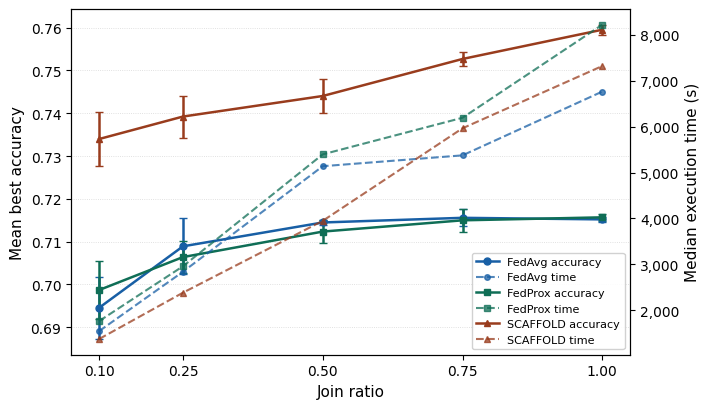

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

os.makedirs("../figures", exist_ok=True)

algos = ["FedAvg", "FedProx", "SCAFFOLD"]

colors = {
    "FedAvg": "#185FA5",
    "FedProx": "#0F6E56",
    "SCAFFOLD": "#993C1D"
}

markers = {
    "FedAvg": "o",
    "FedProx": "s",
    "SCAFFOLD": "^"
}

fig, ax1 = plt.subplots(figsize=(7.2, 4.2))
ax2 = ax1.twinx()

handles = []
labels = []

for algo in algos:
    df_algo = df_summary[df_summary["algorithm"] == algo].sort_values("join_ratio")
    c = colors[algo]
    m = markers[algo]

    acc_line = ax1.errorbar(
        df_algo["join_ratio"],
        df_algo["best_acc_mean"],
        yerr=df_algo["best_acc_std"],
        color=c,
        marker=m,
        linestyle="-",
        linewidth=1.8,
        markersize=5,
        capsize=3,
        label=f"{algo} accuracy"
    )

    time_line, = ax2.plot(
        df_algo["join_ratio"],
        df_algo["total_time_median"],
        color=c,
        marker=m,
        linestyle="--",
        linewidth=1.5,
        markersize=4,
        alpha=0.75,
        label=f"{algo} time"
    )

    handles.append(acc_line.lines[0])
    labels.append(f"{algo} accuracy")
    handles.append(time_line)
    labels.append(f"{algo} time")

ax1.set_xlabel("Join ratio", fontsize=11)
ax1.set_ylabel("Mean best accuracy", fontsize=11)
ax2.set_ylabel("Median execution time (s)", fontsize=11)

ax1.set_xlim(0.05, 1.05)
ax1.set_xticks(sorted(df_summary["join_ratio"].unique()))

ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax1.tick_params(labelsize=10)
ax2.tick_params(labelsize=10)

ax1.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.5)

ax1.legend(
    handles,
    labels,
    loc="lower right",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    ncol=1
)

fig.tight_layout()

plt.savefig("../figures/fig_accuracy_time_join_ratio.pdf", dpi=300, bbox_inches="tight")
plt.savefig("../figures/fig_accuracy_time_join_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# =============================================================================
# Figure: Accuracy-time trade-off scatter plot
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

out_dir = Path.home() / "research" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

alg_colors = {
    "FedAvg": "C0",
    "FedProx": "C1",
    "SCAFFOLD": "C2",
}

alg_markers = {
    "FedAvg": "o",
    "FedProx": "s",
    "SCAFFOLD": "^",
}

fig, ax = plt.subplots(figsize=(6.4, 4.0))

for algo in ["FedAvg", "FedProx", "SCAFFOLD"]:
    df_algo = df_summary[df_summary["algorithm"] == algo].sort_values("join_ratio")

    ax.plot(
        df_algo["total_time_median"],
        df_algo["best_acc_mean"],
        marker=alg_markers[algo],
        color=alg_colors[algo],
        linewidth=1.5,
        markersize=6,
        label=algo
    )

ax.set_xlabel("Median execution time (s)")
ax.set_ylabel("Mean best accuracy")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.text(
    0.02,
    0.97,
    "Points follow increasing join ratio: 0.10 → 1.00",
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.9)
)

ax.legend(
    title="Algorithm",
    fontsize=8,
    title_fontsize=8,
    loc="lower right"
)

fig.tight_layout()

pdf_path = out_dir / "fig_scatter_tradeoff.pdf"
png_path = out_dir / "fig_scatter_tradeoff.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.close(fig)

print(f"✓ saved: {pdf_path.resolve()}")
print(f"✓ saved: {png_path.resolve()}")

✓ saved: /home/joaobbb/research/figures/fig_scatter_tradeoff.pdf
✓ saved: /home/joaobbb/research/figures/fig_scatter_tradeoff.png


In [47]:
# identificar melhor acurácia por join ratio
best_idx = df_summary.groupby("join_ratio")["best_acc_mean"].idxmax().values

# criar df_table primeiro
df_table = df_summary.copy()

df_table["accuracy"] = [
    f"\\textbf{{{row['best_acc_mean']:.4f}}} $\\pm$ {row['best_acc_std']:.4f}"
    if idx in best_idx
    else f"{row['best_acc_mean']:.4f} $\\pm$ {row['best_acc_std']:.4f}"
    for idx, row in df_summary.iterrows()
]

df_table["time (s)"] = df_summary["total_time_median"].apply(lambda x: f"{int(x)}")
df_table["gpu (\\%)"] = df_summary["gpu_mean_mean"].apply(lambda x: f"{x:.1f}")
df_table["join ratio"] = df_summary["join_ratio"].apply(lambda x: f"{x:.2f}")

df_latex = df_table[["algorithm", "join ratio", "accuracy", "time (s)", "gpu (\\%)"]].copy()
df_latex.columns = ["Algorithm", "Join Ratio", "Accuracy (mean $\\pm$ std)", "Time median (s)", "GPU mean (\\%)"]

latex_str = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="llccc",
    caption="Performance and computational cost across algorithms and join ratios.",
    label="tab:results",
    position="t"
)

output_path = "../figures/tab_results.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(latex_str)

from pathlib import Path
print(f"✓ saved: {Path(output_path).resolve()}")

✓ saved: /home/joaobbb/research/git/fl-join-ratio-paper/figures/tab_results.tex


In [48]:
# =============================================================================
# Table: Statistical analysis
# =============================================================================

from pathlib import Path
from scipy import stats
import itertools
import pandas as pd

algos = ["FedAvg", "FedProx", "SCAFFOLD"]
jrs = sorted(df_results["join_ratio"].unique())

rows = []

for jr in jrs:
    grupos = {
        algo: df_results[
            (df_results["algorithm"] == algo) &
            (df_results["join_ratio"] == jr)
        ]["best_acc"].values
        for algo in algos
    }

    stat_kw, p_kw = stats.kruskal(*grupos.values())

    pares = list(itertools.combinations(algos, 2))
    pw_results = {}

    for a1, a2 in pares:
        _, p = stats.mannwhitneyu(grupos[a1], grupos[a2], alternative="two-sided")
        pw_results[f"{a1} vs {a2}"] = p

    rows.append({
        "join_ratio": jr,
        "kw_stat": stat_kw,
        "kw_p": p_kw,
        **pw_results
    })

df_stat = pd.DataFrame(rows)

def fmt_p(p):
    if p < 0.001:
        return "$< 0.001$"
    return f"{p:.3f}"

# montar linhas da tabela manualmente
table_rows = []

for _, row in df_stat.iterrows():
    table_rows.append(
        f"{row['join_ratio']:.2f} & "
        f"{row['kw_stat']:.2f} & "
        f"{fmt_p(row['kw_p'])} & "
        f"{fmt_p(row['FedAvg vs FedProx'])} & "
        f"{fmt_p(row['FedAvg vs SCAFFOLD'])} & "
        f"{fmt_p(row['FedProx vs SCAFFOLD'])} \\\\"
    )

table_body = "\n".join(table_rows)

tab_stat = rf"""
\begin{{table}}[t]
\caption{{Statistical comparison of best test accuracy across algorithms for each join ratio value. Kruskal-Wallis test with pairwise Mann-Whitney U post hoc comparisons. Bold values indicate $p < 0.05$.}}
\label{{tab:stat}}
\centering
\footnotesize
\setlength{{\tabcolsep}}{{5pt}}
\resizebox{{\columnwidth}}{{!}}{{%
\begin{{tabular}}{{lccccc}}
\toprule
\textbf{{Join ratio}} & \textbf{{KW stat}} & \textbf{{KW $p$}} & \textbf{{FA--FP}} & \textbf{{FA--SC}} & \textbf{{FP--SC}} \\
\midrule
{table_body}
\bottomrule
\end{{tabular}}%
}}
\vspace{{1mm}}
\scriptsize
\noindent FA = FedAvg, FP = FedProx, SC = SCAFFOLD.
\end{{table}}
"""

output_path = "../figures/tab_stat.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(tab_stat.strip() + "\n")

print(f"✓ saved: {Path(output_path).resolve()}")

✓ saved: /home/joaobbb/research/git/fl-join-ratio-paper/figures/tab_stat.tex


In [49]:
# =============================================================================
# CÉLULA 1 — Imports e configuração
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Caminhos ─────────────────────────────────────────────────────────────────
BASE_DIR = Path.home() / "research" / "experiments" / "fashionmnist_gpu"

# ── Mapeamento de pastas → valores numéricos de join ratio ───────────────────
JR_MAP = {
    "jr01":  0.10,
    "jr025": 0.25,
    "jr05":  0.50,
    "jr075": 0.75,
    "jr10":  1.00,
}

# ── Plataforma experimental desta análise ────────────────────────────────────
# Todos os dados usados nesta análise energética foram gerados no mesmo hardware:
# Notebook : Dell Inspiron 14 5000 (i14-5490-A40S / Inspiron 5490)
# CPU      : Intel Core i7 de 10ª geração
# GPU      : NVIDIA GeForce MX230 2GB
# Memória  : 16 GB
#
# Modelo de potência:
# - CPU e GPU são estimadas proporcionalmente à utilização observada
# - RAM e consumo base entram como parcelas fixas
# - A GPU MX230 não expõe power.draw no nvidia-smi, então usa-se proxy por TDP
#
# Observação:
# - pidstat reporta %CPU agregado por thread
# - nesta máquina, assume-se máximo reportável de 800% (8 threads lógicas)

HARDWARE_NAME = "Dell Inspiron 14 5490 (i7 10th Gen + MX230)"
CPU_TDP_W     = 15.0
GPU_TDP_W     = 10.0
RAM_W         = 4.0
BASELINE_W    = 2.0
CPU_MAX_PCT   = 800.0
DT_SECONDS    = 1.0

# ── Estilo dos gráficos ───────────────────────────────────────────────────────
COLORS = {
    "FedAvg":   "#1f77b4",
    "FedProx":  "#ff7f0e",
    "SCAFFOLD": "#2ca02c",
}

MARKERS = {
    "FedAvg":   "o",
    "FedProx":  "s",
    "SCAFFOLD": "^",
}

print("✓ Configuração carregada.")
print(f"  BASE_DIR            : {BASE_DIR}")
print(f"  Hardware            : {HARDWARE_NAME}")
print(f"  CPU_TDP_W           : {CPU_TDP_W}")
print(f"  GPU_TDP_W           : {GPU_TDP_W}")
print(f"  RAM_W               : {RAM_W}")
print(f"  BASELINE_W          : {BASELINE_W}")
print(f"  CPU_MAX_PCT         : {CPU_MAX_PCT}")
print(f"  DT_SECONDS          : {DT_SECONDS}")
print(f"  Algoritmos esperados: {list(COLORS.keys())}")
print(f"  Join ratios         : {list(JR_MAP.values())}")

✓ Configuração carregada.
  BASE_DIR            : /home/joaobbb/research/experiments/fashionmnist_gpu
  Hardware            : Dell Inspiron 14 5490 (i7 10th Gen + MX230)
  CPU_TDP_W           : 15.0
  GPU_TDP_W           : 10.0
  RAM_W               : 4.0
  BASELINE_W          : 2.0
  CPU_MAX_PCT         : 800.0
  DT_SECONDS          : 1.0
  Algoritmos esperados: ['FedAvg', 'FedProx', 'SCAFFOLD']
  Join ratios         : [0.1, 0.25, 0.5, 0.75, 1.0]


In [50]:
# =============================================================================
# CÉLULA 2 — Funções de leitura dos logs
# =============================================================================

def load_cpu_log(path: Path) -> np.ndarray:
    """
    Lê um cpu_usage.log gerado pelo pidstat e devolve um array
    de utilização de CPU normalizada em [0, 1].

    Suposição:
    - a coluna %CPU está no índice 7 após split()
    - pidstat reporta %CPU agregado por threads
    - nesta máquina, o máximo reportável adotado é CPU_MAX_PCT = 800
    """
    values = []

    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()

            # Ignora cabeçalhos e linhas vazias
            if (
                not line
                or line.startswith("#")
                or line.startswith("Linux")
                or line.startswith("Average:")
            ):
                continue

            parts = line.split()
            if len(parts) >= 8:
                try:
                    cpu_raw = float(parts[7].replace(",", "."))
                    values.append(cpu_raw)
                except ValueError:
                    continue

    if not values:
        return np.array([], dtype=float)

    cpu_norm = np.array(values, dtype=float) / CPU_MAX_PCT
    return np.clip(cpu_norm, 0.0, 1.0)


def load_gpu_csv(path: Path) -> np.ndarray:
    """
    Lê um gpu_usage.csv gerado pelo nvidia-smi e devolve um array
    de utilização de GPU normalizada em [0, 1].

    Observação:
    - a MX230 não expõe power.draw no nvidia-smi
    - por isso, usa-se apenas utilization_gpu_pct como proxy de carga
    """
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        if "utilization_gpu_pct" not in df.columns:
            print(f"⚠ coluna 'utilization_gpu_pct' ausente em: {path}")
            return np.array([], dtype=float)

        gpu_norm = pd.to_numeric(df["utilization_gpu_pct"], errors="coerce").dropna().values / 100.0
        return np.clip(gpu_norm.astype(float), 0.0, 1.0)

    except Exception as e:
        print(f"⚠ erro ao ler GPU log {path}: {e}")
        return np.array([], dtype=float)


def compute_energy_joules(
    cpu_norm: np.ndarray,
    gpu_norm: np.ndarray,
    dt: float = DT_SECONDS
) -> dict:
    len_cpu = len(cpu_norm)
    len_gpu = len(gpu_norm)

    if len_cpu == 0 or len_gpu == 0:
        return {}

    delta = abs(len_cpu - len_gpu)
    rel_delta = delta / max(len_cpu, len_gpu)

    # aceita desalinhamentos pequenos ou percentualmente irrelevantes
    if delta > 30 and rel_delta > 0.01:
        print(f"⚠ desalinhamento crítico CPU/GPU: {len_cpu} vs {len_gpu}")
        return {}
    elif delta > 2:
        print(f"⚠ desalinhamento moderado CPU/GPU: {len_cpu} vs {len_gpu}; usando janela comum")

    n = min(len_cpu, len_gpu)
    if n == 0:
        return {}

    cpu_slice = cpu_norm[:n]
    gpu_slice = gpu_norm[:n]

    p_cpu = cpu_slice * CPU_TDP_W
    p_gpu = gpu_slice * GPU_TDP_W
    p_total = p_cpu + p_gpu + RAM_W + BASELINE_W

    return {
        "n_samples": n,
        "duration_s": n * dt,
        "cpu_util_mean": float(cpu_slice.mean()),
        "gpu_util_mean": float(gpu_slice.mean()),
        "p_cpu_mean_w": float(p_cpu.mean()),
        "p_gpu_mean_w": float(p_gpu.mean()),
        "p_mean_w": float(p_total.mean()),
        "p_peak_w": float(p_total.max()),
        "energy_j": float(p_total.sum() * dt),
    }

    # Checagem de plausibilidade contra o teto do adaptador (~65 W)
    if result["p_peak_w"] > 65.0:
        print(f"⚠ pico de potência estimado acima de 65 W: {result['p_peak_w']:.2f} W")

    return result


print("✓ Funções de leitura definidas.")

✓ Funções de leitura definidas.


In [51]:
# =============================================================================
# CÉLULA 3 — Varredura de todos os experimentos
# =============================================================================

if not BASE_DIR.exists():
    raise FileNotFoundError(f"BASE_DIR não encontrada: {BASE_DIR}")

records = []
issues = []

expected_algorithms = list(COLORS.keys())
expected_jr_folders = list(JR_MAP.keys())

# Repetições excluídas manualmente da análise principal
EXCLUDED_REPS = {
    ("SCAFFOLD", "jr075", "rep6_rerun_outlier"),
}

for alg in expected_algorithms:
    alg_dir = BASE_DIR / alg

    if not alg_dir.exists() or not alg_dir.is_dir():
        issues.append({
            "algorithm": alg,
            "jr_folder": None,
            "rep": None,
            "issue": "alg_dir_missing",
            "detail": str(alg_dir),
        })
        print(f"⚠ diretório de algoritmo ausente: {alg_dir}")
        continue

    for jr_folder in expected_jr_folders:
        jr_dir = alg_dir / jr_folder
        jr_val = JR_MAP[jr_folder]

        if not jr_dir.exists() or not jr_dir.is_dir():
            issues.append({
                "algorithm": alg,
                "jr_folder": jr_folder,
                "rep": None,
                "issue": "jr_dir_missing",
                "detail": str(jr_dir),
            })
            print(f"⚠ diretório de join ratio ausente: {alg}/{jr_folder}")
            continue

        rep_dirs = sorted([p for p in jr_dir.iterdir() if p.is_dir()])

        if not rep_dirs:
            issues.append({
                "algorithm": alg,
                "jr_folder": jr_folder,
                "rep": None,
                "issue": "no_rep_dirs",
                "detail": str(jr_dir),
            })
            print(f"⚠ nenhuma repetição encontrada em: {alg}/{jr_folder}")
            continue

        for rep_dir in rep_dirs:
            rep = rep_dir.name

            if (alg, jr_folder, rep) in EXCLUDED_REPS:
                print(f"⚠ repetição excluída manualmente: {alg}/{jr_folder}/{rep}")
                continue

            cpu_path = rep_dir / "cpu_usage.log"
            gpu_path = rep_dir / "gpu_usage.csv"

            if not cpu_path.exists() or not gpu_path.exists():
                missing_parts = []
                if not cpu_path.exists():
                    missing_parts.append("cpu_usage.log")
                if not gpu_path.exists():
                    missing_parts.append("gpu_usage.csv")

                issues.append({
                    "algorithm": alg,
                    "jr_folder": jr_folder,
                    "rep": rep,
                    "issue": "missing_logs",
                    "detail": ", ".join(missing_parts),
                })
                print(f"⚠ logs ausentes: {alg}/{jr_folder}/{rep} -> {', '.join(missing_parts)}")
                continue

            cpu_norm = load_cpu_log(cpu_path)
            gpu_norm = load_gpu_csv(gpu_path)
            energy = compute_energy_joules(cpu_norm, gpu_norm, dt=DT_SECONDS)

            if not energy:
                issues.append({
                    "algorithm": alg,
                    "jr_folder": jr_folder,
                    "rep": rep,
                    "issue": "invalid_or_empty_logs",
                    "detail": f"cpu_len={len(cpu_norm)}, gpu_len={len(gpu_norm)}",
                })
                print(f"⚠ log inválido/vazio: {alg}/{jr_folder}/{rep} "
                      f"(cpu_len={len(cpu_norm)}, gpu_len={len(gpu_norm)})")
                continue

            records.append({
                "algorithm": alg,
                "jr_folder": jr_folder,
                "join_ratio": jr_val,
                "rep": rep,
                **energy,
            })

df_raw = pd.DataFrame(records)
df_issues = pd.DataFrame(issues)

if df_raw.empty:
    raise ValueError("Nenhuma repetição válida foi carregada. Verifique a estrutura das pastas e os logs.")

print(f"\n✓ Varredura concluída: {len(df_raw)} repetições válidas lidas.")

print("\nDistribuição de repetições válidas por algoritmo e join ratio:")
print(
    df_raw.groupby(["algorithm", "jr_folder"])
          .size()
          .rename("n_valid")
          .to_string()
)

if not df_issues.empty:
    print("\nResumo de problemas encontrados:")
    print(df_issues["issue"].value_counts().to_string())
else:
    print("\n✓ Nenhum problema encontrado durante a varredura.")

⚠ desalinhamento moderado CPU/GPU: 1602 vs 1599; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 1627 vs 1624; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 2840 vs 2834; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 2245 vs 2241; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 2777 vs 2772; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 4077 vs 4068; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 3779 vs 3771; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 6780 vs 6766; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 6695 vs 6679; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 5034 vs 5024; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 3923 vs 3915; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 3669 vs 3663; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 5892 vs 5882; usando janela comum
⚠ desalinhamento moderado CPU/GPU: 5619 vs 5608; usando janela comum
⚠ desalinhamento moderado CPU/GPU:

In [52]:
# =============================================================================
# CÉLULA 4 — Agregar por (algoritmo, join_ratio) e incorporar acurácia
# =============================================================================

# ── Agregação dos logs reais por (algorithm, join_ratio) ─────────────────────
agg = (
    df_raw
    .groupby(["algorithm", "join_ratio"])
    .agg(
        n_reps             = ("rep", "count"),

        cpu_util_mean_mean = ("cpu_util_mean", "mean"),
        cpu_util_mean_std  = ("cpu_util_mean", "std"),

        gpu_util_mean_mean = ("gpu_util_mean", "mean"),
        gpu_util_mean_std  = ("gpu_util_mean", "std"),

        p_cpu_mean_w_mean  = ("p_cpu_mean_w", "mean"),
        p_cpu_mean_w_std   = ("p_cpu_mean_w", "std"),

        p_gpu_mean_w_mean  = ("p_gpu_mean_w", "mean"),
        p_gpu_mean_w_std   = ("p_gpu_mean_w", "std"),

        p_mean_w_mean      = ("p_mean_w", "mean"),
        p_mean_w_std       = ("p_mean_w", "std"),

        p_peak_w_max       = ("p_peak_w", "max"),

        duration_s_mean    = ("duration_s", "mean"),
        duration_s_median  = ("duration_s", "median"),
        duration_s_std     = ("duration_s", "std"),

        energy_j_mean      = ("energy_j", "mean"),
        energy_j_median    = ("energy_j", "median"),
        energy_j_std       = ("energy_j", "std"),
    )
    .reset_index()
)

# ── Puxar acurácia e tempo diretamente do df_summary ──────────────────────────
required_summary_cols = [
    "algorithm",
    "join_ratio",
    "best_acc_mean",
    "best_acc_std",
    "total_time_median",
]

missing = [c for c in required_summary_cols if c not in df_summary.columns]
if missing:
    raise ValueError(f"Colunas ausentes em df_summary: {missing}")

df_acc = (
    df_summary[required_summary_cols]
    .copy()
    .rename(columns={"total_time_median": "time_median_s_article"})
)

# segurança: evitar duplicatas inesperadas
dup_mask = df_acc.duplicated(subset=["algorithm", "join_ratio"], keep=False)
if dup_mask.any():
    raise ValueError(
        "Há duplicatas em df_summary para (algorithm, join_ratio):\n"
        + df_acc.loc[dup_mask, ["algorithm", "join_ratio"]].to_string(index=False)
    )

# ── Merge entre energia dos logs e métricas principais do experimento ─────────
df = agg.merge(
    df_acc,
    on=["algorithm", "join_ratio"],
    how="inner",
    validate="one_to_one"
)

# ── Checagens ─────────────────────────────────────────────────────────────────
expected_configs = len(COLORS) * len(JR_MAP)
if len(df) != expected_configs:
    raise ValueError(
        f"Número inesperado de configurações agregadas: {len(df)} "
        f"(esperado: {expected_configs})"
    )

if not (df["n_reps"] == 5).all():
    print("⚠ Atenção: nem todas as configurações têm 5 repetições.")
    print(df[["algorithm", "join_ratio", "n_reps"]].to_string(index=False))

# ── Métricas finais baseadas diretamente nos logs ─────────────────────────────
df["energy_wh_median"] = df["energy_j_median"] / 3600.0
df["energy_kj_median"] = df["energy_j_median"] / 1000.0
df["efficiency_acc_per_kj"] = df["best_acc_mean"] / df["energy_kj_median"]

# comparação auxiliar entre tempo do artigo e tempo mediano observado nos logs
df["time_delta_article_vs_logs_s"] = df["time_median_s_article"] - df["duration_s_median"]

df = df.sort_values(["algorithm", "join_ratio"]).reset_index(drop=True)

print("✓ DataFrame final agregado:")
cols_show = [
    "algorithm",
    "join_ratio",
    "n_reps",
    "best_acc_mean",
    "best_acc_std",
    "duration_s_median",
    "time_median_s_article",
    "p_mean_w_mean",
    "energy_j_median",
    "energy_wh_median",
    "efficiency_acc_per_kj",
]
print(df[cols_show].to_string(index=False))

✓ DataFrame final agregado:
algorithm  join_ratio  n_reps  best_acc_mean  best_acc_std  duration_s_median  time_median_s_article  p_mean_w_mean  energy_j_median  energy_wh_median  efficiency_acc_per_kj
   FedAvg        0.10       5       0.694560      0.007288             1457.0               1546.820      13.459343     18177.069938          5.049186               0.038211
   FedAvg        0.25       5       0.708914      0.006544             2834.0               2840.180      15.234186     42651.127813         11.847536               0.016621
   FedAvg        0.50       5       0.714480      0.000624             5024.0               5137.620      16.059831     81714.527875         22.698480               0.008744
   FedAvg        0.75       5       0.715566      0.001956             5269.0               5373.790      15.639372     83698.801063         23.249667               0.008549
   FedAvg        1.00       5       0.715200      0.000591             6753.0               6762.510  

In [53]:
from pathlib import Path

tab_results_energy = r"""
\begin{table*}[t]
\centering
\caption{Performance, computational cost, and estimated energy across configurations. The reported energy corresponds to the median estimated from synchronized CPU and GPU utilization logs over five repetitions per configuration.}
\label{tab:results_energy}
\footnotesize
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.12}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\toprule
Algorithm & \textit{Join ratio} & Best test acc. (mean $\pm$ std.) & Time median (s) & $P_{\mathrm{avg}}$ (W) & Est. energy median (J) & Eff. (best acc./kJ) \\
\midrule

FedAvg & 0.10 & $0.6946 \pm 0.0073$ & 1,457 & 13.46 & 18,177 & $\mathbf{0.0382}$ \\
 & 0.25 & $0.7089 \pm 0.0065$ & 2,834 & 15.23 & 42,651 & $0.0166$ \\
 & 0.50 & $0.7145 \pm 0.0006$ & 5,024 & 16.06 & 81,715 & $0.0087$ \\
 & 0.75 & $0.7156 \pm 0.0020$ & 5,269 & 15.64 & 83,699 & $\mathbf{0.0085}$ \\
 & 1.00 & $0.7152 \pm 0.0006$ & 6,753 & 15.52 & 106,602 & $0.0067$ \\
\midrule

FedProx & 0.10 & $0.6987 \pm 0.0068$ & 1,768 & 14.58 & 26,336 & $0.0265$ \\
 & 0.25 & $0.7064 \pm 0.0038$ & 2,959 & 15.73 & 45,800 & $0.0154$ \\
 & 0.50 & $0.7124 \pm 0.0027$ & 5,388 & 15.54 & 81,180 & $0.0088$ \\
 & 0.75 & $0.7150 \pm 0.0026$ & 6,185 & 15.18 & 95,131 & $0.0075$ \\
 & 1.00 & $0.7157 \pm 0.0009$ & 8,205 & 15.48 & 129,322 & $0.0055$ \\
\midrule

SCAFFOLD & 0.10 & $\mathbf{0.7340 \pm 0.0063}$ & 1,378 & 14.11 & 19,429 & $0.0378$ \\
 & 0.25 & $\mathbf{0.7392 \pm 0.0049}$ & 2,384 & 14.76 & 35,525 & $\mathbf{0.0208}$ \\
 & 0.50 & $\mathbf{0.7440 \pm 0.0040}$ & 3,946 & 14.90 & 59,752 & $\mathbf{0.0125}$ \\
 & 0.75 & $\mathbf{0.7527 \pm 0.0015}$ & 5,851 & 15.81 & 92,416 & $0.0081$ \\
 & 1.00 & $\mathbf{0.7595 \pm 0.0012}$ & 7,310 & 15.42 & 108,474 & $\mathbf{0.0070}$ \\

\bottomrule
\end{tabular}%
}
\end{table*}
"""

output_path = "../figures/tab_results_energy.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(tab_results_energy.strip() + "\n")

print(f"✓ saved: {Path(output_path).resolve()}")

✓ saved: /home/joaobbb/research/git/fl-join-ratio-paper/figures/tab_results_energy.tex


  ✓ saved: /home/joaobbb/research/figures/fig_tradeoff_accuracy_energy.pdf
  ✓ saved: /home/joaobbb/research/figures/fig_tradeoff_accuracy_energy.png


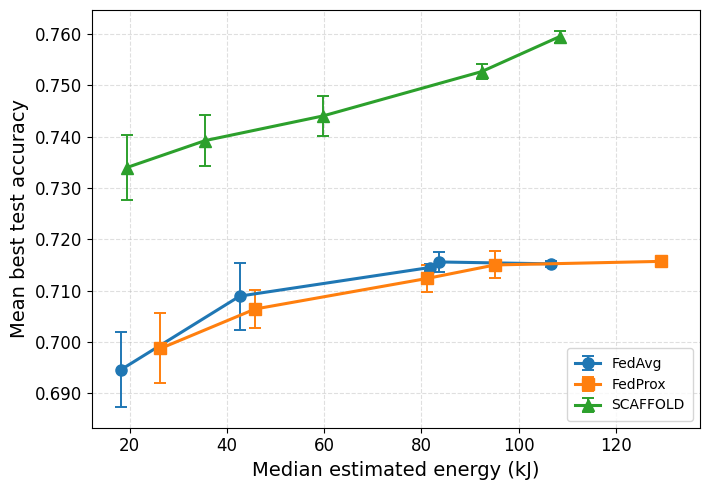

In [54]:
# =============================================================================
# Figure: Accuracy-energy trade-off
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

def save_fig(fig: plt.Figure, stem: str):
    out_dir = Path.home() / "research" / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        p = out_dir / f"{stem}.{ext}"
        fig.savefig(p, dpi=300, bbox_inches="tight")
        print(f"  ✓ saved: {p}")

LABEL_FS   = 14
TICK_FS    = 12
LEGEND_FS  = 10

fig1, ax1 = plt.subplots(figsize=(7.2, 5.0))

for alg, grp in df.groupby("algorithm"):
    grp = grp.sort_values("join_ratio")

    x  = grp["energy_j_median"].values / 1000.0   # kJ
    y  = grp["best_acc_mean"].values
    ye = grp["best_acc_std"].values

    ax1.errorbar(
        x, y, yerr=ye,
        color=COLORS[alg],
        marker=MARKERS[alg],
        linewidth=2.2,
        markersize=8,
        capsize=4,
        capthick=1.4,
        elinewidth=1.4,
        label=alg,
        zorder=3
    )

ax1.set_xlabel("Median estimated energy (kJ)", fontsize=LABEL_FS)
ax1.set_ylabel("Mean best test accuracy", fontsize=LABEL_FS)

ax1.tick_params(axis="both", labelsize=TICK_FS)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax1.grid(True, linestyle="--", alpha=0.4)

ax1.legend(
    fontsize=LEGEND_FS,
    loc="lower right",
    frameon=True,
    borderpad=0.6,
    handlelength=1.8
)

x_min = df["energy_j_median"].min() / 1000.0
x_max = df["energy_j_median"].max() / 1000.0
y_min = (df["best_acc_mean"] - df["best_acc_std"]).min()
y_max = (df["best_acc_mean"] + df["best_acc_std"]).max()

ax1.set_xlim(x_min - 6, x_max + 8)
ax1.set_ylim(y_min - 0.004, y_max + 0.004)

plt.tight_layout()
save_fig(fig1, "fig_tradeoff_accuracy_energy")
plt.show()

   algorithm  join_ratio  best_acc_mean  energy_j_median  efficiency
0     FedAvg        0.10       0.694560     18177.069938    0.038211
1     FedAvg        0.25       0.708914     42651.127813    0.016621
2     FedAvg        0.50       0.714480     81714.527875    0.008744
3     FedAvg        0.75       0.715566     83698.801063    0.008549
4     FedAvg        1.00       0.715200    106602.055187    0.006709
5    FedProx        0.10       0.698709     26335.701688    0.026531
6    FedProx        0.25       0.706400     45800.046938    0.015424
7    FedProx        0.50       0.712354     81180.437812    0.008775
8    FedProx        0.75       0.714983     95130.880063    0.007516
9    FedProx        1.00       0.715680    129321.974312    0.005534
10  SCAFFOLD        0.10       0.733966     19429.070437    0.037777
11  SCAFFOLD        0.25       0.739211     35525.456125    0.020808
12  SCAFFOLD        0.50       0.744011     59751.836688    0.012452
13  SCAFFOLD        0.75       0.7

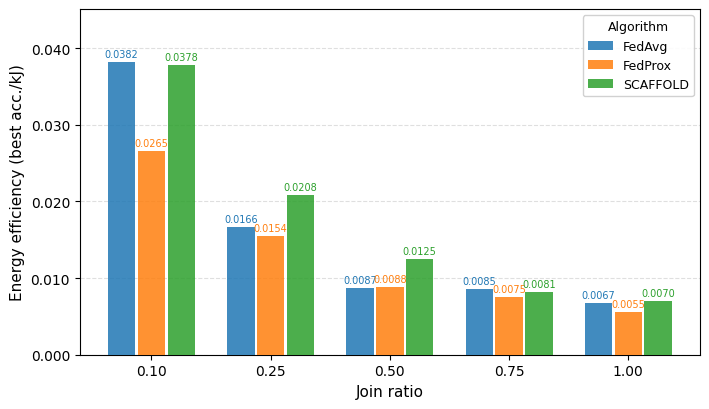

In [55]:
# =============================================================================
# Figure: Energy efficiency by configuration
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Safety copy
df_eff = df.copy()

# Clean algorithm names
df_eff["algorithm"] = df_eff["algorithm"].astype(str).str.strip()

# Ensure numeric columns
df_eff["join_ratio"] = pd.to_numeric(df_eff["join_ratio"], errors="coerce")
df_eff["best_acc_mean"] = pd.to_numeric(df_eff["best_acc_mean"], errors="coerce")
df_eff["energy_j_median"] = pd.to_numeric(df_eff["energy_j_median"], errors="coerce")

# Recompute efficiency if needed
if "efficiency" not in df_eff.columns or df_eff["efficiency"].isna().all():
    df_eff["efficiency"] = df_eff["best_acc_mean"] / (df_eff["energy_j_median"] / 1000.0)
else:
    df_eff["efficiency"] = pd.to_numeric(df_eff["efficiency"], errors="coerce")

# Remove incomplete rows
df_eff = df_eff.dropna(subset=["algorithm", "join_ratio", "efficiency"])

# Diagnostic check
print(df_eff[["algorithm", "join_ratio", "best_acc_mean", "energy_j_median", "efficiency"]])

fig2, ax2 = plt.subplots(figsize=(7.2, 4.2))

algs = ["FedAvg", "FedProx", "SCAFFOLD"]
jrs = sorted(df_eff["join_ratio"].unique())

x_pos = np.arange(len(jrs))
width = 0.25
offsets = [-width, 0, width]

for i, alg in enumerate(algs):
    grp = df_eff[df_eff["algorithm"] == alg].sort_values("join_ratio")

    if grp.empty:
        print(f"Warning: no data found for {alg}")
        continue

    # Align values with join ratio positions
    vals = []
    for jr in jrs:
        row = grp[grp["join_ratio"] == jr]
        if row.empty:
            vals.append(np.nan)
        else:
            vals.append(row["efficiency"].iloc[0])

    bars = ax2.bar(
        x_pos + offsets[i],
        vals,
        width=width - 0.02,
        color=COLORS[alg],
        label=alg,
        alpha=0.85,
        zorder=3
    )

    for bar, v in zip(bars, vals):
        if np.isnan(v):
            continue

        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0004,
            f"{v:.4f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=COLORS[alg]
        )

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{jr:.2f}" for jr in jrs])

ax2.set_xlabel("Join ratio", fontsize=11)
ax2.set_ylabel("Energy efficiency (best acc./kJ)", fontsize=11)

ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax2.tick_params(labelsize=10)

ax2.grid(True, axis="y", linestyle="--", alpha=0.4, zorder=0)

ax2.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    title="Algorithm",
    title_fontsize=9
)

# Add space above labels
y_max = df_eff["efficiency"].max()
ax2.set_ylim(0, y_max * 1.18)

plt.tight_layout()

save_fig(fig2, "fig_energy_efficiency")
plt.show()

  ✓ saved: /home/joaobbb/research/figures/fig_energy_join_ratio.pdf
  ✓ saved: /home/joaobbb/research/figures/fig_energy_join_ratio.png


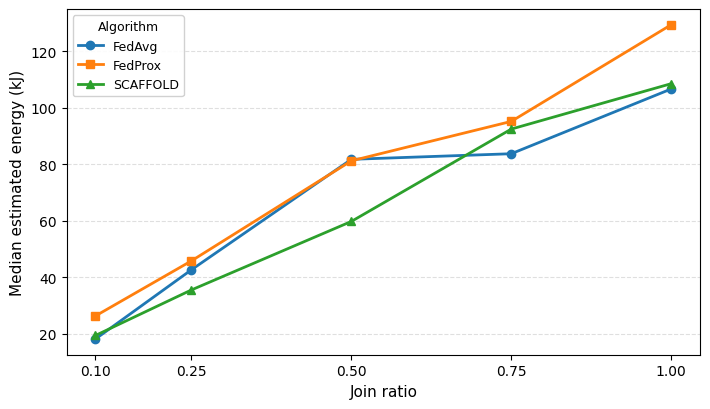

In [56]:
# =============================================================================
# Figure: Median estimated energy as a function of join ratio
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(7.2, 4.2))

for alg, grp in df.groupby("algorithm"):
    grp = grp.sort_values("join_ratio")

    ax.plot(
        grp["join_ratio"],
        grp["energy_j_median"] / 1000.0,  # convert J to kJ
        color=COLORS[alg],
        marker=MARKERS[alg],
        linewidth=2.0,
        markersize=6,
        label=alg
    )

ax.set_xlabel("Join ratio", fontsize=11)
ax.set_ylabel("Median estimated energy (kJ)", fontsize=11)

ax.set_xticks(sorted(df["join_ratio"].unique()))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))

ax.tick_params(labelsize=10)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    title="Algorithm",
    title_fontsize=9
)

plt.tight_layout()

save_fig(fig, "fig_energy_join_ratio")
plt.show()

  ✓ saved: /home/joaobbb/research/figures/fig_average_power_join_ratio.pdf
  ✓ saved: /home/joaobbb/research/figures/fig_average_power_join_ratio.png


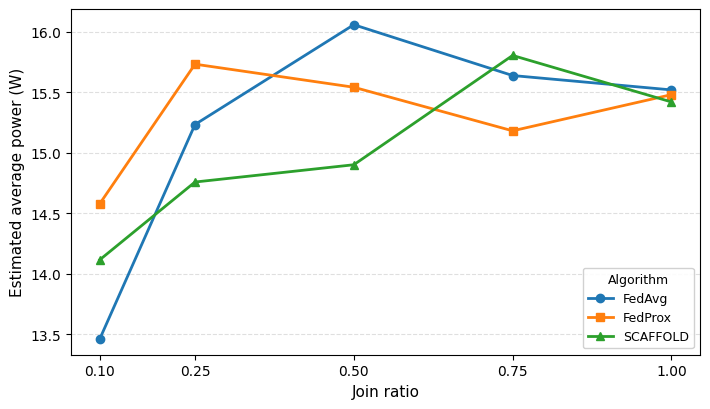

In [57]:
# =============================================================================
# Figure: Estimated average power as a function of join ratio
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Try to identify the average power column
possible_power_cols = [
    "p_mean_w_mean",
    "avg_power_w",
    "avg_power_mean",
    "power_w_mean",
    "p_mean_w_median"
]

power_col = None
for col in possible_power_cols:
    if col in df.columns:
        power_col = col
        break

if power_col is None:
    raise ValueError(
        "No average power column found. Available columns are:\n"
        + "\n".join(df.columns)
    )

fig, ax = plt.subplots(figsize=(7.2, 4.2))

for alg, grp in df.groupby("algorithm"):
    grp = grp.sort_values("join_ratio")

    ax.plot(
        grp["join_ratio"],
        grp[power_col],
        color=COLORS[alg],
        marker=MARKERS[alg],
        linewidth=2.0,
        markersize=6,
        label=alg
    )

ax.set_xlabel("Join ratio", fontsize=11)
ax.set_ylabel("Estimated average power (W)", fontsize=11)

ax.set_xticks(sorted(df["join_ratio"].unique()))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

ax.tick_params(labelsize=10)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

ax.legend(
    loc="lower right",
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    title="Algorithm",
    title_fontsize=9
)

plt.tight_layout()

save_fig(fig, "fig_average_power_join_ratio")
plt.show()

In [58]:
# =============================================================================
# Table: Simulation parameters
# =============================================================================

from pathlib import Path

out_dir = Path.home() / "research" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

tab_simulation_parameters = r"""
\begin{table}[t]
\centering
\caption{Experimental setup and simulation parameters.}
\label{tab:parameters}
\footnotesize
\setlength{\tabcolsep}{4pt}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{ll}
\toprule
\textbf{Parameter} & \textbf{Value} \\
\midrule
Framework & PFLlib \\
Dataset & FashionMNIST \\
Model & CNN (FedAvgCNN) \\
Optimization algorithms & FedAvg, FedProx, SCAFFOLD \\
Number of clients & 100 \\
\textit{Join ratio} values & 0.10, 0.25, 0.50, 0.75, 1.00 \\
Clients per round & 10, 25, 50, 75, 100 \\
Number of global rounds & 50 \\
Local epochs & 5 \\
Batch size & 10 \\
Learning rate & 0.01 \\
Data partition & non-IID, balanced, pathological \\
Partition script parameters & \texttt{noniid balance pat} \\
Repetitions per configuration & 5 \\
Total configurations & 15 \\
Total executions & 75 \\
Execution environment & Local WSL2 environment \\
Resource monitoring & \texttt{pidstat} and \texttt{nvidia-smi} \\
\bottomrule
\end{tabular}%
}
\end{table}
"""

path = out_dir / "tab_simulation_parameters.tex"
path.write_text(tab_simulation_parameters.strip() + "\n", encoding="utf-8")

print(f"✓ saved: {path.resolve()}")

✓ saved: /home/joaobbb/research/figures/tab_simulation_parameters.tex


In [59]:
# =============================================================================
# Figure: Overview of the experimental protocol (TikZ)
# =============================================================================

from pathlib import Path

out_dir = Path.home() / "research" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

fig_overview_protocol = r"""
\begin{figure*}[t]
\centering
\footnotesize
\begin{tikzpicture}[
    box/.style={
        draw,
        rounded corners=2pt,
        align=center,
        inner sep=3pt,
        minimum height=9mm,
        font=\footnotesize
    },
    smallbox/.style={
        draw,
        rounded corners=2pt,
        align=center,
        inner sep=3pt,
        minimum height=8mm,
        font=\scriptsize
    },
    arrow/.style={
        -{Latex[length=2mm,width=1.5mm]},
        thick
    }
]

% ---------- row 1 ----------
\node[box, text width=18mm] (data) at (-0.8,0)
{\textbf{Dataset}\\FashionMNIST};

\node[box, text width=22mm] (split) at (2.5,0)
{\textbf{Federated split}\\100 clients\\non-IID};

\node[box, text width=22mm] (alg) at (6,0)
{\textbf{Algorithms}\\FedAvg\\FedProx\\SCAFFOLD};

% ---------- row 2 ----------
\node[box, text width=32mm] (jr) at (0,-2.15)
{\textbf{Main variable}\\\textit{Join ratio}\\0.10, 0.25, 0.50, 0.75, 1.00};

\node[box, text width=34mm] (train) at (5.4,-2.15)
{\textbf{Fixed setup}\\50 global rounds\\5 local epochs\\5 repetitions};

% ---------- outputs ----------
\node[box, text width=28mm] (out) at (9.8,-1.05)
{\textbf{Outputs}\\Best test acc.\\Time\\Est. energy\\Eff. (best acc./kJ)};

% ---------- row 3 ----------
\node[smallbox, text width=120mm] (env) at (4.9,-3.8)
{\textbf{Environment \& monitoring}\\PFLlib, WSL2, PyTorch 2.1.0, \textit{pidstat} (CPU), \textit{nvidia-smi} (GPU)};

% ---------- arrows ----------
\draw[arrow] (data.east) -- (split.west);
\draw[arrow] (split.east) -- (alg.west);
\draw[arrow] (jr.east) -- (train.west);

\draw[arrow] (alg.east) -- ++(0.55,0) |- (out.west);
\draw[arrow] (train.east) -- ++(0.55,0) |- (out.west);

\end{tikzpicture}
\caption{Overview of the experimental protocol. The study isolates the \textit{join ratio} as the main variable while keeping the dataset partitioning strategy, training budget, and monitoring procedure fixed across configurations.}
\label{fig:overview_protocol}
\end{figure*}
"""

path = out_dir / "fig_overview_protocol.tex"
path.write_text(fig_overview_protocol.strip() + "\n", encoding="utf-8")

print(f"✓ saved: {path.resolve()}")

✓ saved: /home/joaobbb/research/figures/fig_overview_protocol.tex


In [60]:
# =============================================================================
# Table: Related work comparison
# =============================================================================

from pathlib import Path

out_dir = Path.home() / "research" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

tab_related_work = r"""
\begin{table*}[t]
\centering
\caption{Comparison between related work and this study.}
\label{tab:related_work}
\footnotesize
\setlength{\tabcolsep}{4pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{p{2.7cm}p{3.7cm}p{4.2cm}p{5.0cm}}
\toprule
\textbf{Work} & \textbf{Main focus} & \textbf{Treatment of participation or cost} & \textbf{Limitation addressed by this study} \\
\midrule

McMahan et al.~\cite{mcmahan2017communication} &
FedAvg and communication-efficient FL. &
Uses partial client participation to reduce communication overhead. &
Does not isolate the \textit{join ratio} as the main variable nor evaluate the accuracy--cost trade-off. \\

Cho et al.~\cite{cho2020client} &
Client selection and convergence in FL. &
Shows that selected clients can affect convergence and model quality. &
Focuses on selection strategies, not on fixed \textit{join ratio} levels and their cost implications. \\

Maciel et al.~\cite{maciel2024federated} &
Energy-aware client selection. &
Uses participant selection to reduce energy consumption in FL. &
Targets adaptive selection, while this study quantifies the effect of predefined \textit{join ratio} values. \\

Qiu et al.~\cite{qiu2023carbon} &
Carbon footprint of FL. &
Evaluates environmental impact associated with federated training. &
Does not focus on the \textit{join ratio} as a design variable for accuracy, time, and energy trade-offs. \\

Savazzi et al.~\cite{savazzi2023energy} &
Energy and carbon analysis of distributed and federated learning. &
Analyzes resource and environmental costs in distributed training. &
Provides a broader energy analysis, but does not isolate fixed participation levels across FL algorithms. \\

\midrule

\textbf{This work} &
\textbf{Impact of client participation on the performance--cost trade-off in FL.} &
\textbf{Treats the \textit{join ratio} as the main experimental variable and evaluates best test accuracy, execution time, estimated energy, and efficiency.} &
\textbf{Shows how increasing participation leads to diminishing returns under a controlled comparison of FedAvg, FedProx, and SCAFFOLD.} \\

\bottomrule
\end{tabular}%
}
\end{table*}
"""

path = out_dir / "tab_related_work.tex"
path.write_text(tab_related_work.strip() + "\n", encoding="utf-8")

print(f"✓ saved: {path.resolve()}", flush=True)
print(f"  size: {path.stat().st_size} bytes", flush=True)

✓ saved: /home/joaobbb/research/figures/tab_related_work.tex
  size: 2145 bytes


In [61]:
# =============================================================================
# Table: Federated optimization algorithms comparison
# =============================================================================

from pathlib import Path

out_dir = Path.home() / "research" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

tab_alg_comparison = r"""
\begin{table*}[t]
\centering
\caption{Comparative summary of the federated optimization algorithms evaluated in this study.}
\label{tab:alg_comparison}
\footnotesize
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.15}
\resizebox{\textwidth}{!}{%
\begin{tabular}{p{3.0cm}p{4.0cm}p{4.5cm}p{4.8cm}}
\toprule
\textbf{Aspect} & \textbf{FedAvg} & \textbf{FedProx} & \textbf{SCAFFOLD} \\
\midrule

Core idea &
Standard federated averaging baseline. &
Federated optimization with proximal regularization. &
Federated optimization with drift correction. \\

Main mechanism &
Aggregates local model updates from the selected clients through weighted averaging. &
Adds a proximal term to the local objective to constrain client updates with respect to the global model. &
Uses server-side and client-side control variates to reduce client drift caused by data heterogeneity. \\

Main strength &
Simple, widely used, and communication-efficient. &
Improves local training stability under heterogeneous client data. &
Provides stronger correction for statistical heterogeneity and client drift. \\

Additional state &
No additional correction variables are required. &
No server-client control variates are required, but local objectives are modified. &
Requires maintaining and updating control variates at both server and client levels. \\

Role in this study &
Serves as the reference baseline for analyzing the effect of the join ratio. &
Tests whether proximal regularization improves the performance/cost trade-off. &
Tests whether drift correction leads to more favorable operating points across join ratio values. \\

\bottomrule
\end{tabular}%
}
\end{table*}
"""

path = out_dir / "tab_alg_comparison.tex"
path.write_text(tab_alg_comparison.strip() + "\n", encoding="utf-8")

print(f"✓ saved: {path.resolve()}", flush=True)
print(f"  size: {path.stat().st_size} bytes", flush=True)

✓ saved: /home/joaobbb/research/figures/tab_alg_comparison.tex
  size: 1666 bytes


In [62]:
# =============================================================================
# CÉLULA 8 — Sumário executivo (para copiar na seção de resultados)
# =============================================================================

best  = df.loc[df["efficiency_acc_per_kj"].idxmax()]
worst = df.loc[df["efficiency_acc_per_kj"].idxmin()]

sc10  = df[(df["algorithm"] == "SCAFFOLD") & (df["join_ratio"] == 0.10)].iloc[0]
fa100 = df[(df["algorithm"] == "FedAvg")   & (df["join_ratio"] == 1.00)].iloc[0]

ratio_e   = fa100["energy_j_median"] / sc10["energy_j_median"]
ratio_eff = sc10["efficiency_acc_per_kj"] / worst["efficiency_acc_per_kj"]

print("=" * 70)
print("  SUMÁRIO EXECUTIVO — ANÁLISE ENERGÉTICA")
print("=" * 70)

print(f"\n  Potência média do sistema (média entre configurações): "
      f"{df['p_mean_w_mean'].mean():.2f} W")

print(f"\n  Configuração mais eficiente:")
print(f"    {best['algorithm']} jr={best['join_ratio']:.2f} "
      f"→ {best['efficiency_acc_per_kj']:.5f} acc/kJ")

print(f"\n  Configuração menos eficiente:")
print(f"    {worst['algorithm']} jr={worst['join_ratio']:.2f} "
      f"→ {worst['efficiency_acc_per_kj']:.5f} acc/kJ")

print(f"\n  Comparação de destaque — SCAFFOLD jr=0.10 vs FedAvg jr=1.00:")
print(f"    Acurácia : {sc10['best_acc_mean']:.4f} vs {fa100['best_acc_mean']:.4f} "
      f"(diferença = {sc10['best_acc_mean'] - fa100['best_acc_mean']:+.4f})")

print(f"    Energia  : {sc10['energy_j_median']:,.0f} J vs "
      f"{fa100['energy_j_median']:,.0f} J")

print(f"    Razão    : FedAvg jr=1.00 consome {ratio_e:.1f}× mais energia")

print(f"    Eficiência relativa: SCAFFOLD jr=0.10 é {ratio_eff:.1f}× mais eficiente "
      f"que o pior caso observado ({worst['algorithm']} jr={worst['join_ratio']:.2f})")

print("=" * 70)

  SUMÁRIO EXECUTIVO — ANÁLISE ENERGÉTICA

  Potência média do sistema (média entre configurações): 15.16 W

  Configuração mais eficiente:
    FedAvg jr=0.10 → 0.03821 acc/kJ

  Configuração menos eficiente:
    FedProx jr=1.00 → 0.00553 acc/kJ

  Comparação de destaque — SCAFFOLD jr=0.10 vs FedAvg jr=1.00:
    Acurácia : 0.7340 vs 0.7152 (diferença = +0.0188)
    Energia  : 19,429 J vs 106,602 J
    Razão    : FedAvg jr=1.00 consome 5.5× mais energia
    Eficiência relativa: SCAFFOLD jr=0.10 é 6.8× mais eficiente que o pior caso observado (FedProx jr=1.00)
